In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, KBinsDiscretizer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import pickle

SEED = 42

# 1. Préparation des données
## 1.1 Récupération des données

In [2]:
df_orig = pd.read_csv("../data/export.csv", sep=";")
df = df_orig.copy()

print("Original data shape", df_orig.shape)

print("Users", df_orig.shape[0])
print("Variables", df_orig.columns.get_loc("CONTENTS") - 1)
print("Contenus", df_orig.shape[1] - df.columns.get_loc("CONTENTS"))

Original data shape (31991, 479)
Users 31991
Variables 51
Contenus 427


/var/folders/wv/l5b9d65d6170hn122_d3qcvw0000gp/T/ipykernel_16664/3659686550.py:1: DtypeWarning: Columns (0: MOTIVATION_VALUE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orig = pd.read_csv("../data/export.csv", sep=";")


## 1.2 Nettoyage des données

In [3]:
CONTENTS_THRESHOLD = 0.3
USERS_THRESHOLD = 0.35

df["CONTENTS"] = "X"

# suppression des variables pour lesquelles il y a moins de 40% de users
threshold = df.shape[0] * USERS_THRESHOLD
df = df.dropna(axis=1, thresh=threshold)

# Récupérer les colonnes après "CONTENTS"
cols_after = df.columns[df.columns.get_loc("CONTENTS")+1:]

# Calcul des proportions de 1 pour ces colonnes
proportions = df[cols_after].mean()


# Garder celles entre P et 1-P
cols_to_keep = proportions[(proportions >= CONTENTS_THRESHOLD) & (proportions <= 1-CONTENTS_THRESHOLD)].index
content_vals = df[cols_to_keep].columns
# Construire le nouveau DataFrame
df = pd.concat([df.loc[:, :"CONTENTS"], df[cols_to_keep]], axis=1)

df = df[~((df["MP_ALLER_VERS_SOCRATE"] == 1) & 
          (df["MP_EVITEMENT_SOCRATE"] == 1))]
df = df[~((df["MP_PROCEDURE_SOCRATE"] == 1) & 
          (df["MP_OPTION_SOCRATE"] == 1))]

df.drop(columns=["user id", "MP_PROCEDURE_SOCRATE", "MP_ALLER_VERS_SOCRATE"], inplace=True)

print("Final size", df.shape)

print("Users", df.shape[0])
print("Variables", df.columns.get_loc("CONTENTS") - 1)
print("Contenus", df.shape[1] - df.columns.get_loc("CONTENTS") - 1)

Final size (31988, 17)
Users 31988
Variables 8
Contenus 7


## 1.3 Division des colonnes par type

In [4]:
CAT_COLS = list()
BIN_COLS = list()
NUM_COLS = list()


for c in df.columns[:df.columns.get_loc("CONTENTS")]:

    if df[c].dtype == "str":
        CAT_COLS.append(c)
        continue

    if df[c].dtype in ["float64", "int"] and len(df[c].value_counts()) == 2:
        BIN_COLS.append(c)
        continue

    NUM_COLS.append(c)

print(f"Colonnes numériques: {len(NUM_COLS)}", NUM_COLS)
print(f"Colonnes discrètes: {len(BIN_COLS)}", BIN_COLS)
print(f"Colonnes catégorielles: {len(CAT_COLS)}", CAT_COLS)

Colonnes numériques: 1 ['USER_AGE']
Colonnes discrètes: 6 ['MP_EVITEMENT_SOCRATE', 'MP_OPTION_SOCRATE', 'USER_OWNS_MASK', 'USER_OWNS_SUBSCRIPTION', 'USER_USE_ANDROID', 'USER_USE_IOS']
Colonnes catégorielles: 2 ['USER_GENDER', 'USER_APP_LANGUAGE']


## 1.4 Colonne numérique

### 1.4.1 Nettoyage des outliners

In [5]:
imputer = KNNImputer()
df_median = df.copy()
df_median[NUM_COLS] = imputer.fit_transform(df_median[NUM_COLS])
z_scores = stats.zscore(df_median[NUM_COLS])
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)

df_z_filtered = df_median[filtered_entries]

outlier_indices_z = df_median.index[~filtered_entries].tolist()
print(f"Outliers détectés par Z-Score: {(~filtered_entries).sum()} observations")
print(f"Index des outliers (Z-Score): {outlier_indices_z}")
print(f"Nouvelles dimensions: {df_z_filtered.shape}")
print(f"Anciennes dimensions: {df.shape}")

df = df_z_filtered

Outliers détectés par Z-Score: 420 observations
Index des outliers (Z-Score): [2, 8, 157, 338, 364, 446, 470, 495, 682, 724, 890, 975, 1011, 1183, 1258, 1405, 1556, 1743, 1747, 1755, 1814, 1839, 1894, 1921, 1923, 1929, 1950, 1961, 2234, 2311, 2472, 2530, 2545, 2685, 2710, 2789, 2847, 2894, 3127, 3189, 3218, 3470, 3590, 3596, 3676, 3794, 3801, 3881, 3910, 3964, 3993, 4034, 4200, 4302, 4429, 4536, 4561, 4649, 4655, 4665, 4765, 4814, 4818, 4888, 5044, 5055, 5102, 5119, 5207, 5220, 5360, 5488, 5520, 5552, 5677, 5700, 6030, 6053, 6084, 6172, 6229, 6467, 6474, 6779, 6790, 6884, 6893, 6987, 7108, 7136, 7175, 7261, 7337, 7381, 7535, 7547, 7579, 7617, 7686, 7832, 7857, 7913, 8028, 8042, 8065, 8330, 8331, 8398, 8407, 8409, 8431, 8438, 8525, 8526, 8547, 8722, 8779, 8793, 8807, 8949, 8981, 9054, 9095, 9138, 9167, 9258, 9277, 9429, 9534, 9543, 9610, 9620, 9902, 9916, 9954, 10072, 10121, 10185, 10274, 10344, 10874, 10981, 11139, 11291, 11303, 11369, 11398, 11424, 11621, 11661, 11786, 11903, 11984, 1

### 1.4.2 Distribution des valeurs numériques

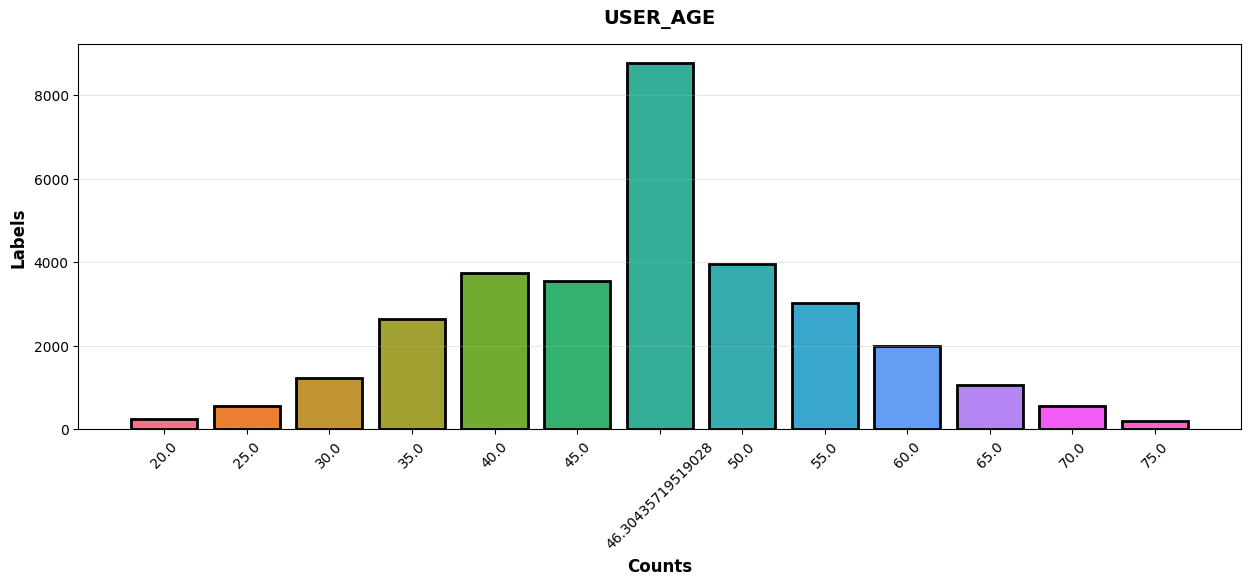

In [6]:
NUM_VAR = NUM_COLS[0]
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

values = df[NUM_VAR].value_counts(sort=False).sort_index()
colors = sns.color_palette("husl", len(values))
bars = ax.bar(range(len(values)), values.values, color=colors, edgecolor='black', linewidth=2)
ax.set_xlabel('Counts', fontsize=12, fontweight='bold')
ax.set_ylabel('Labels', fontsize=12, fontweight='bold')
ax.set_title(NUM_VAR, fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(values)))
ax.set_xticklabels(values.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)


## 1.5 Jeu de données final

In [7]:
X = df[NUM_COLS + CAT_COLS + BIN_COLS]
print(f"Data shape: {X.shape}")
X.describe()

Data shape: (31568, 9)


,USER_AGE,MP_EVITEMENT_SOCRATE,MP_OPTION_SOCRATE,USER_OWNS_MASK,USER_OWNS_SUBSCRIPTION,USER_USE_ANDROID,USER_USE_IOS
count,31568.000000,13201.000000,13200.000000,31568.000000,31568.000000,31568.000000,31568.000000
mean,46.624866,0.619499,0.842803,0.684681,0.452357,0.594716,0.455239
std,9.324571,0.485529,0.364000,0.464650,0.497733,0.490955,0.498000
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,46.304357,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1.6 Exploration des données (PCA)

[0.40048264 0.21332166 0.19047823 0.11729466 0.0450884  0.03333442]


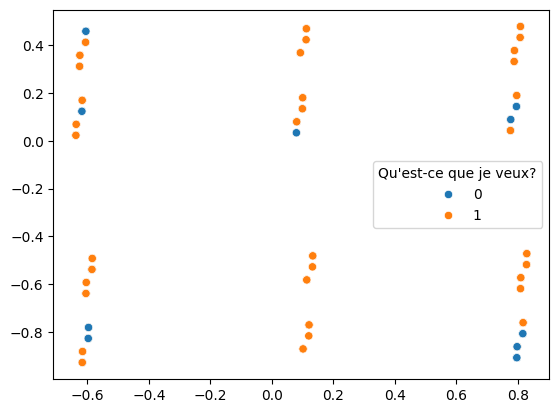

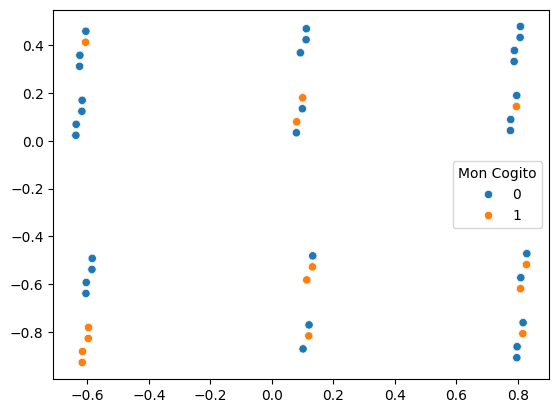

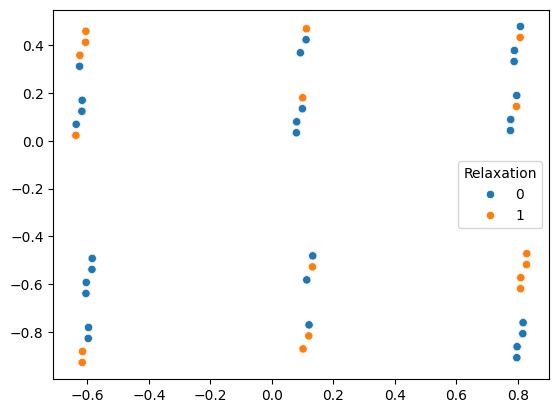

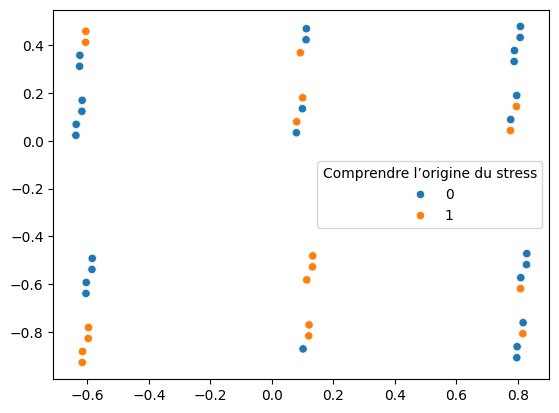

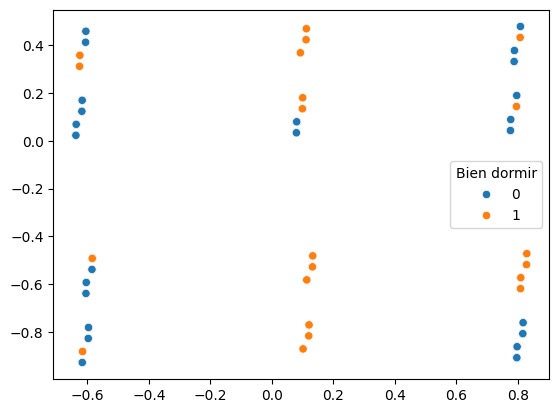

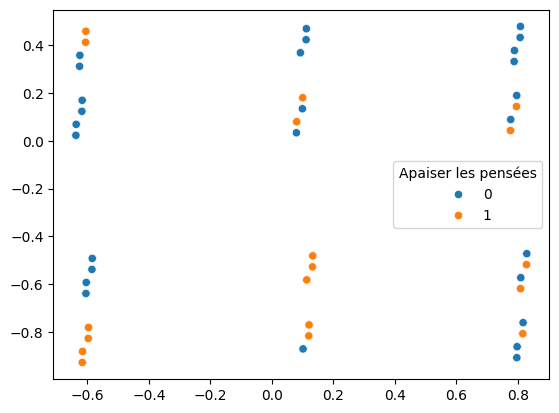

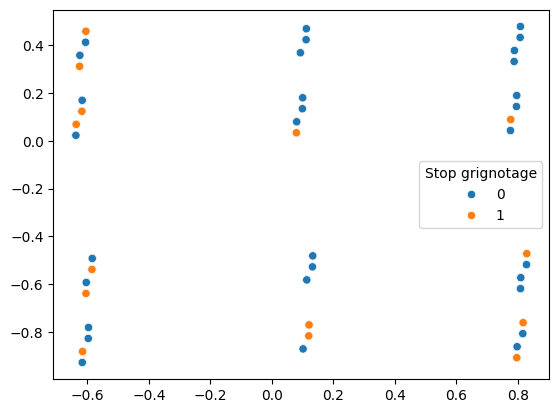

In [8]:
df_scatter = df.select_dtypes(include='number').dropna()
X_scatter = df_scatter[BIN_COLS]
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scatter)
print(pca.explained_variance_ratio_)

for idx, k in enumerate(content_vals):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_scatter[k])
    plt.show()

# 2. Recherche du meilleur estimator
## 2.1 Préparation du pipeline

In [9]:
def encode_lang(x):
    return (x == "fr").astype(int)

def encode_gender(x):
    return (x == "WOM").astype(int)

In [10]:
numeric_preprocess = Pipeline([
    ("imputer", KNNImputer()),
    ("scaler", StandardScaler()),
])

cat_preprocess = Pipeline([
    ("imputer", KNNImputer()),
])

lang_preprocess = Pipeline([
    ("encode", FunctionTransformer(encode_lang)),
    ("imputer", KNNImputer()),
])

gender_preprocess = Pipeline([
    ("encode", FunctionTransformer(encode_gender)),
    ("imputer", KNNImputer()),
])

preprocess = ColumnTransformer([
    ("lang", lang_preprocess, ["USER_APP_LANGUAGE"]),
    ("gender", lang_preprocess, ["USER_GENDER"]),
    ("num", numeric_preprocess, NUM_COLS),
    ("cat", cat_preprocess, BIN_COLS),
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", None)
])


## 2.2 Grid search

In [11]:
PARAM_GRIDS = {
    "Gradient Boosting": {
        "model": [GradientBoostingClassifier(random_state=SEED)],
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5],
    },
    "Random Forest": {
        "model": [RandomForestClassifier(random_state=SEED)],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [1, 2, 3, 5, 10],
    },
    "Logistic Regression": {
        "model": [LogisticRegression(max_iter=2000, random_state=SEED)],
        "model__C": [0.01, 0.1, 1, 10],
    },
    #"KNN": {
    #    "model": [KNeighborsClassifier()],
    #    "model__n_neighbors": [3, 4, 5, 6, 7],   
    #},
    "SVM": {
        'model': [LinearSVC(random_state=SEED)],
        #'model__kernel': ['rbf', 'linear'],
        'model__C': [0.1, 1, 10],
        #'model__gamma': ['scale', 0.01, 0.1, 1],
    },
}

In [12]:
DATASETS = dict()

for col in content_vals:
    _y = (df[col] != 0).astype(int)

    X_train_raw, _X_test, y_train_raw, _y_test = train_test_split(
        X, _y,
        test_size=0.2,
        stratify=_y,
        random_state=SEED
    )

    _X_train, _X_val, _y_train, _y_val = train_test_split(
        X_train_raw, y_train_raw,
        test_size=0.25,
        stratify=y_train_raw,
        random_state=SEED
    )
    
    print(col,  _y.mean(), _y_train.mean(), _y_test.mean(), _y_val.mean())


    DATASETS[col] = {
        "X_train": _X_train,
        "y_train": _y_train,
        "X_test": _X_test,
        "y_test": _y_test,
        "X_val": _X_val,
        "y_val": _y_val
    }

Qu'est-ce que je veux? 0.4939178915357324 0.49392819429778245 0.4939816281279696 0.4938232499208109
Mon Cogito 0.3140522047643183 0.3140443505807814 0.3140639847956921 0.3140639847956921
Relaxation 0.5124809934110491 0.5124604012671594 0.5125118783655369 0.5125118783655369
Comprendre l’origine du stress 0.3209579320831221 0.320960929250264 0.3210326259106747 0.32087424770351597
Bien dormir 0.5960149518499747 0.5960401267159451 0.5959771935381691 0.5959771935381691
Apaiser les pensées 0.4156424227065383 0.41568109820485744 0.4155844155844156 0.4155844155844156
Stop grignotage 0.30980739989863154 0.3098204857444562 0.30978777320240736 0.30978777320240736


In [13]:
def get_best_estimator(col, estimator_type):

    dataset = DATASETS[col]
    param_grid = PARAM_GRIDS[estimator_type]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    grid_cv = GridSearchCV(    
        pipeline,    
        param_grid=param_grid,     
        cv=cv,
        scoring="roc_auc",
        n_jobs=1
    )

    grid_cv.fit(dataset["X_val"], dataset["y_val"])

    return grid_cv

best_params_for_content = dict()
for col in content_vals:
    print(col)
    best_score = 0.0
    best_g = None
    for estimator in PARAM_GRIDS.keys():
        g = get_best_estimator(col, estimator)

        print("\t", estimator, g.best_score_)
        if g.best_score_ > best_score:
            best_score = g.best_score_
            best_g = g


    best_params_for_content[col] = best_g
    if best_g.best_score_ > 0.75:
        print("BEST", best_g.best_score_, best_g.best_params_)
    else:
        print("BEST but not enough", best_g.best_score_, best_g.best_params_)


Qu'est-ce que je veux?
	 Gradient Boosting 0.9235858877053094
	 Random Forest 0.9214839128202101
	 Logistic Regression 0.8506643676099139
	 SVM 0.8500818531583884
BEST 0.9235858877053094 {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Mon Cogito
	 Gradient Boosting 0.7764522491215016
	 Random Forest 0.7748270694282674
	 Logistic Regression 0.6890708526316177
	 SVM 0.6886690297315491
BEST 0.7764522491215016 {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Relaxation
	 Gradient Boosting 0.8066484451189971
	 Random Forest 0.8050105079826894
	 Logistic Regression 0.7448665212735364
	 SVM 0.743286925338399
BEST 0.8066484451189971 {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Comprendre l’origine du stress
	 Gradient Boosting 0.811297

In [14]:
confusion_data = dict()

for content, params in best_params_for_content.items():
    print(content, params.best_params_)
    X_train = DATASETS[content]["X_train"]
    y_train = DATASETS[content]["y_train"]

    best_pipeline = pipeline.set_params(**params.best_params_)
    best_pipeline.fit(X_train, y_train)

    with open(f"../models/{content}.pkl", "wb") as fn:
        pickle.dump(best_pipeline, fn)
                    
    print("Entrainement fini")

    if isinstance(best_pipeline.steps[1][1], RandomForestClassifier):
        print("Importance des features")
        zip_features = zip(X_train.columns, best_pipeline.steps[1][1].feature_importances_)
        zip_features = sorted(zip_features, key=lambda x: x[1], reverse=True)
        for zf in zip_features:
            print(zf)

    print("Validation")
    X_test = DATASETS[content]["X_test"]

    y_test = DATASETS[content]["y_test"]
    score = best_pipeline.score(X_test, y_test)
    print("Score: ", score)

    # prédictions
    y_pred = best_pipeline.predict(X_test)

    # probabilités
    y_proba = best_pipeline.predict_proba(X_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("ROC AUC:", roc_auc_score(y_test, y_proba))

    print(classification_report(y_test, y_pred))

    confusion_data[content] = (y_test.values, y_pred)

Qu'est-ce que je veux? {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.8492239467849224
Accuracy: 0.8492239467849224
ROC AUC: 0.9244518803175651
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      3195
           1       0.83      0.87      0.85      3119

    accuracy                           0.85      6314
   macro avg       0.85      0.85      0.85      6314
weighted avg       0.85      0.85      0.85      6314

Mon Cogito {'model': GradientBoostingClassifier(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Entrainement fini
Validation
Score:  0.7576813430471967
Accuracy: 0.7576813430471967
ROC AUC: 0.8012656180629324
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      4331
           1       0.59      0.73 

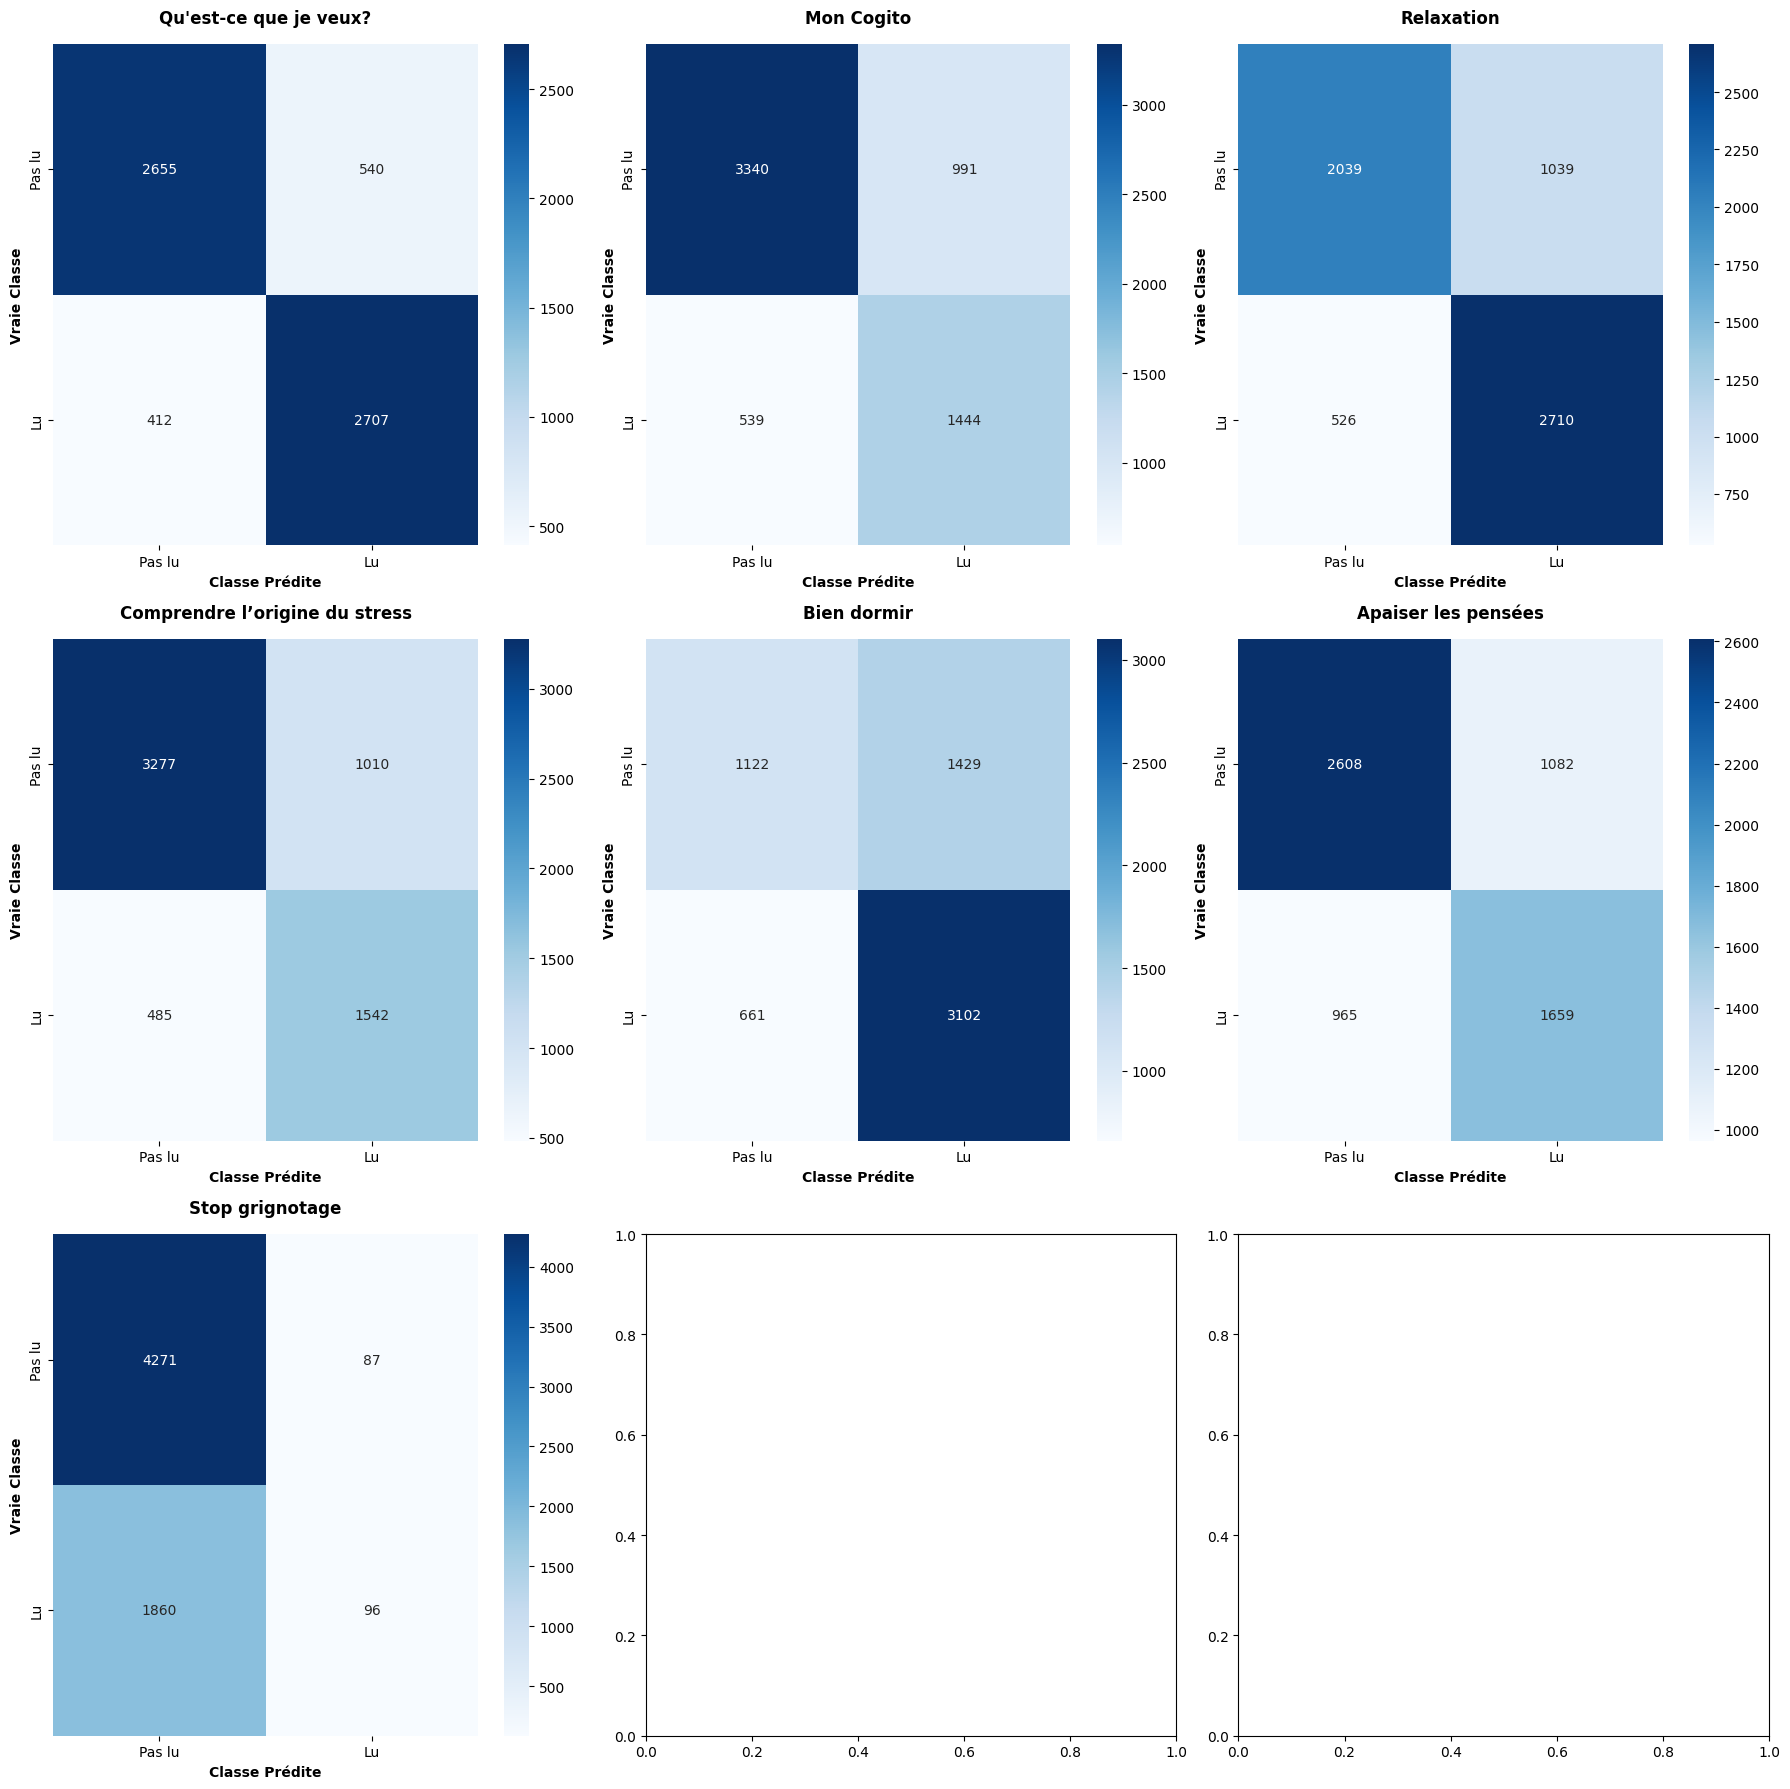

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

predictions = [(content, v[0], v[1]) for content, v in confusion_data.items()]

axes = axes.flatten()

for idx, (name, y_test, y_pred) in enumerate(predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pas lu', 'Lu'],
                yticklabels=['Pas lu', 'Lu'])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold', pad=15)
    axes[idx].set_ylabel('Vraie Classe', fontweight='bold')
    axes[idx].set_xlabel('Classe Prédite', fontweight='bold')

plt.tight_layout()
plt.show()


In [16]:
X.columns

Index(['USER_AGE', 'USER_GENDER', 'USER_APP_LANGUAGE', 'MP_EVITEMENT_SOCRATE',
       'MP_OPTION_SOCRATE', 'USER_OWNS_MASK', 'USER_OWNS_SUBSCRIPTION',
       'USER_USE_ANDROID', 'USER_USE_IOS'],
      dtype='str')